# Air Quality Analysis

Analyzing hourly air quality sensor data to understand pollution trends over time, daily/seasonal patterns, and how pollution relates to weather conditions (temperature, humidity).


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("Air_Quality.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9471, 17)


In [6]:
print(df.columns)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


## 3. Data Cleaning

The raw file has a few known issues: fully empty trailing rows/columns, and missing sensor readings encoded as **-200** instead of NaN.

In [9]:
# Drop completely empty rows and the two unnamed trailing columns
df = df.dropna(how="all")
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")

print("Shape after dropping empty rows/columns:", df.shape)

Shape after dropping empty rows/columns: (9357, 15)


In [10]:
# -200 is used as a placeholder for missing sensor readings — replace with NaN
numeric_cols = df.columns.drop(["Date", "Time"])
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

df.isnull().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [11]:
# NMHC(GT) is missing for ~90% of rows — not usable, drop it
df = df.drop(columns=["NMHC(GT)"], errors="ignore")

# Fill remaining missing sensor values with the column median
for col in df.columns.drop(["Date", "Time"]):
    df[col] = df[col].fillna(df[col].median())

print("Duplicate Rows:", df.duplicated().sum())
df.isnull().sum()

Duplicate Rows: 0


Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

## 4. Build a Proper Datetime Index

In [13]:
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.day_name()

df[["Datetime", "Year", "Month", "Hour", "DayOfWeek"]].head()

,Datetime,Year,Month,Hour,DayOfWeek
0,2004-03-10 18:00:00,2004,3,18,Wednesday
1,2004-03-10 19:00:00,2004,3,19,Wednesday
2,2004-03-10 20:00:00,2004,3,20,Wednesday
3,2004-03-10 21:00:00,2004,3,21,Wednesday
4,2004-03-10 22:00:00,2004,3,22,Wednesday


In [14]:
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,Year,Month,Hour
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357,9357.000000,9357.000000,9357.000000
mean,2.089302,1098.392433,10.009447,937.973923,235.178903,834.339959,112.373303,1456.528054,1020.562894,18.297574,49.248509,1.024352,2004-09-21 16:00:00,2004.240141,6.310356,11.498557
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,2004.000000,1.000000,0.000000
25%,1.200000,941.000000,4.600000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100,2004-06-16 05:00:00,2004.000000,3.000000,5.000000
50%,1.800000,1063.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00,2004.000000,6.000000,11.000000
75%,2.600000,1221.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,2004-12-28 03:00:00,2004.000000,9.000000,18.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,2005.000000,12.000000,23.000000
std,1.323024,212.911465,7.311771,261.625561,195.091025,251.808888,43.948519,339.370072,390.784960,8.658221,16.974949,0.395878,NaN,0.427192,3.438160,6.923182


## 5. Pollution Trend Over Time

Daily average of key pollutants across the full monitoring period.

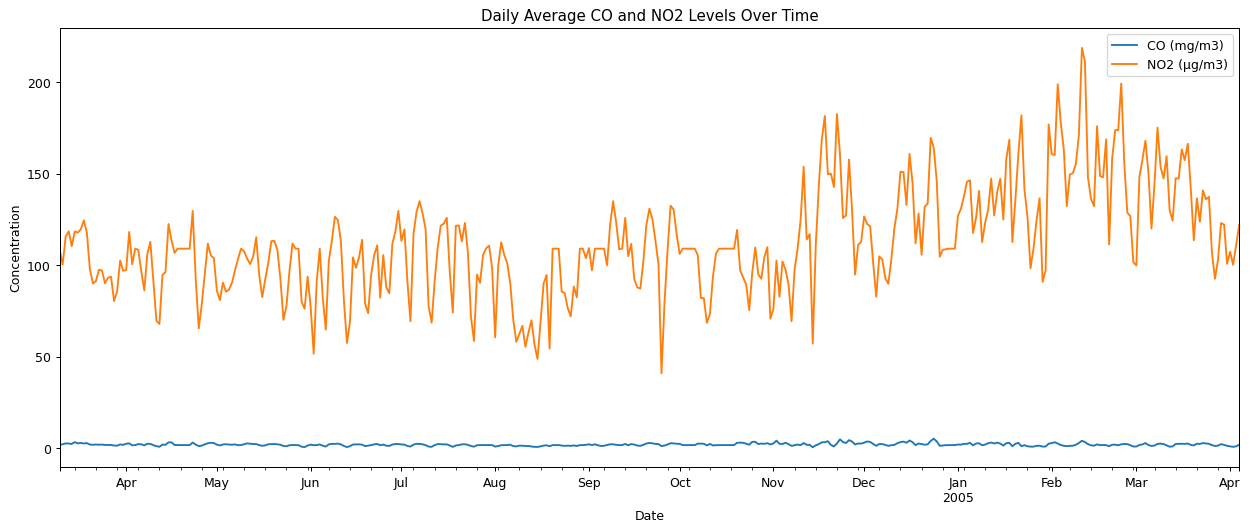

In [16]:
daily = df.set_index("Datetime")[["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 6))
daily["CO(GT)"].plot(ax=ax, label="CO (mg/m3)")
daily["NO2(GT)"].plot(ax=ax, label="NO2 (µg/m3)")
ax.set_title("Daily Average CO and NO2 Levels Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Concentration")
ax.legend()
plt.tight_layout()
plt.show()

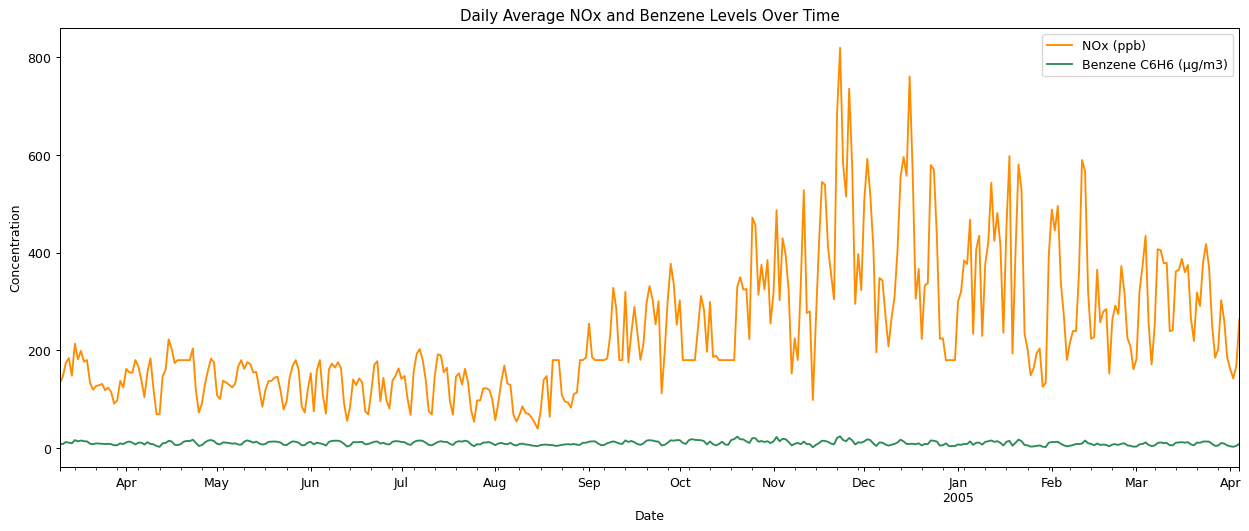

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
daily["NOx(GT)"].plot(ax=ax, color="darkorange", label="NOx (ppb)")
daily["C6H6(GT)"].plot(ax=ax, color="seagreen", label="Benzene C6H6 (µg/m3)")
ax.set_title("Daily Average NOx and Benzene Levels Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Concentration")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Monthly Average Pollution Levels

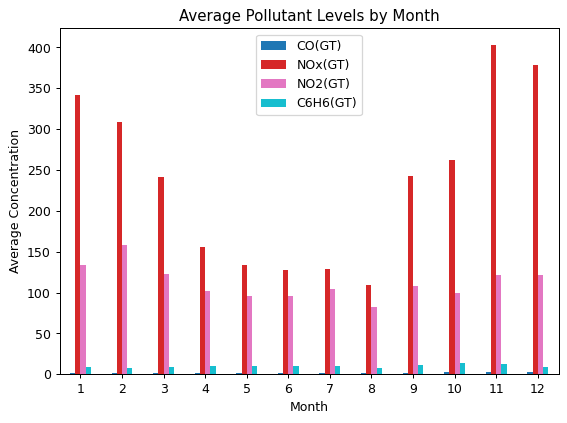

In [19]:
monthly_avg = df.groupby("Month")[["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]].mean()

fig, ax = plt.subplots()
monthly_avg.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Average Pollutant Levels by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Concentration")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Hourly Pollution Pattern (Rush Hour Effect)

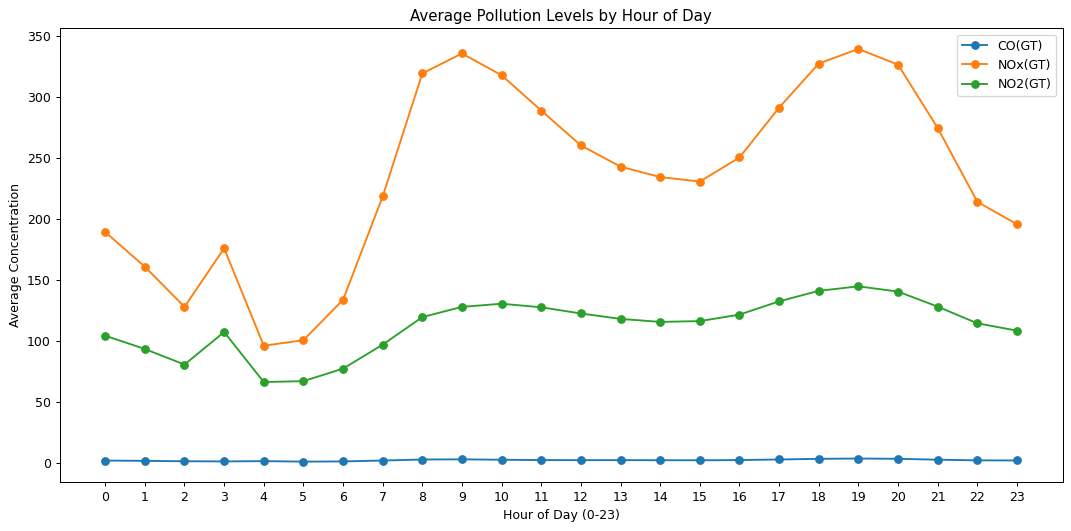

In [21]:
hourly_avg = df.groupby("Hour")[["CO(GT)", "NOx(GT)", "NO2(GT)"]].mean()

fig, ax = plt.subplots(figsize=(12, 6))
hourly_avg.plot(ax=ax, marker="o")
ax.set_title("Average Pollution Levels by Hour of Day")
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Average Concentration")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 8. Pollution by Day of the Week

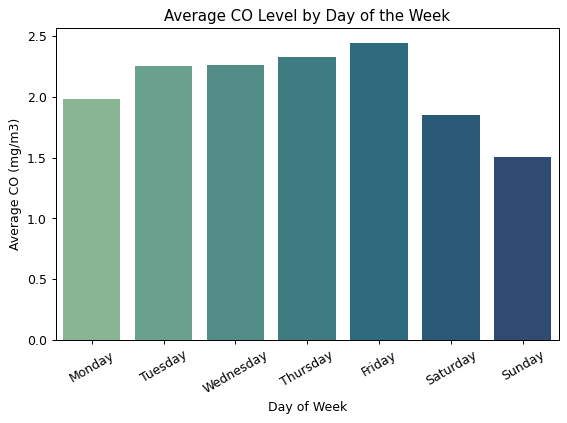

In [23]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = df.groupby("DayOfWeek")["CO(GT)"].mean().reindex(day_order)

fig, ax = plt.subplots()
sns.barplot(x=dow_avg.index, y=dow_avg.values, hue=dow_avg.index, palette="crest", legend=False, ax=ax)
ax.set_title("Average CO Level by Day of the Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average CO (mg/m3)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Relationship Between Pollution and Weather

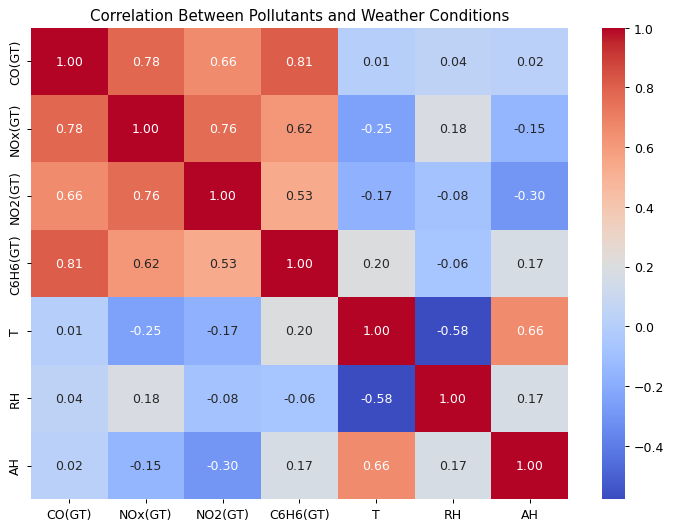

In [25]:
weather_pollution_cols = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "T", "RH", "AH"]
corr = df[weather_pollution_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between Pollutants and Weather Conditions")
plt.tight_layout()
plt.show()

## 10. Pollution vs Temperature

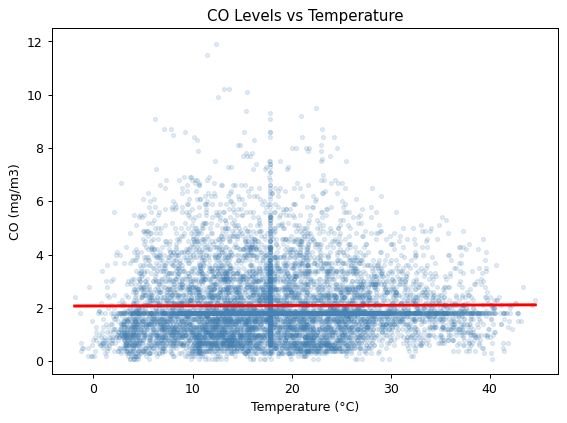

In [27]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="T", y="CO(GT)", scatter_kws={"alpha": 0.15, "s": 10, "color": "steelblue"},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("CO Levels vs Temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("CO (mg/m3)")
plt.tight_layout()
plt.show()

## 11. Pollution vs Humidity

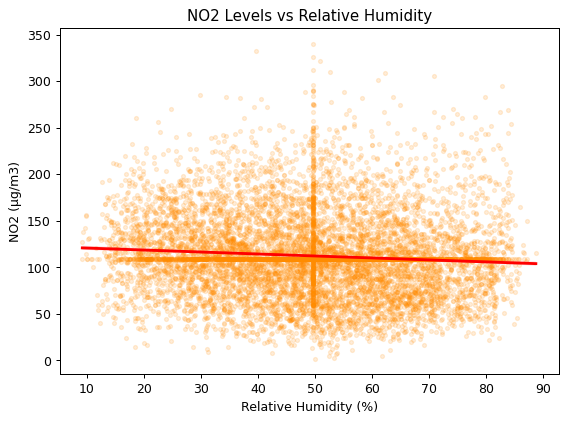

In [29]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="RH", y="NO2(GT)", scatter_kws={"alpha": 0.15, "s": 10, "color": "darkorange"},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("NO2 Levels vs Relative Humidity")
ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("NO2 (µg/m3)")
plt.tight_layout()
plt.show()

## 12. Distribution of Key Pollutants

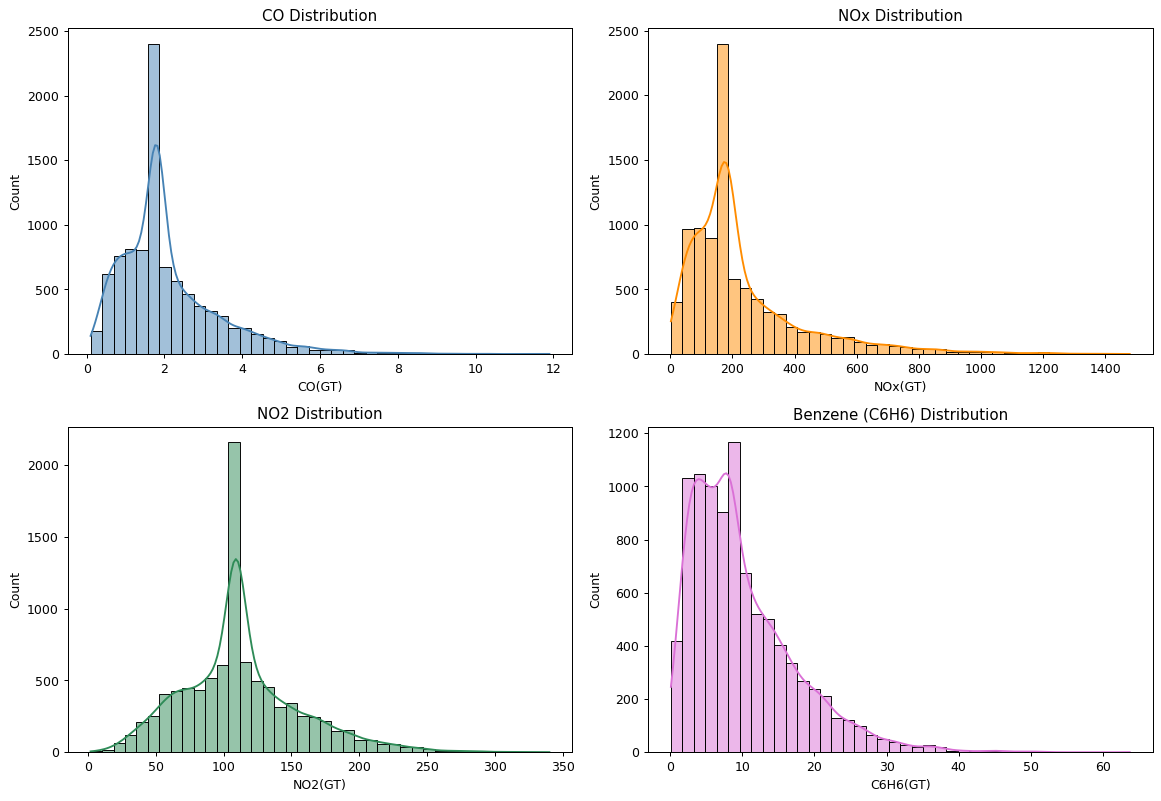

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df["CO(GT)"], bins=40, kde=True, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title("CO Distribution")

sns.histplot(df["NOx(GT)"], bins=40, kde=True, color="darkorange", ax=axes[0, 1])
axes[0, 1].set_title("NOx Distribution")

sns.histplot(df["NO2(GT)"], bins=40, kde=True, color="seagreen", ax=axes[1, 0])
axes[1, 0].set_title("NO2 Distribution")

sns.histplot(df["C6H6(GT)"], bins=40, kde=True, color="orchid", ax=axes[1, 1])
axes[1, 1].set_title("Benzene (C6H6) Distribution")

plt.tight_layout()
plt.show()

## 13. Key Insights

- **CO, NOx, and NO2 levels show a clear rush-hour pattern**, peaking in the morning (~8-9 AM) and evening (~6-8 PM) — consistent with traffic emissions.
- **Pollution is generally higher on weekdays** than weekends, again pointing to traffic and industrial activity as major sources.
- **Temperature is negatively correlated with CO and NOx** — pollutant concentrations tend to be higher during colder months, likely due to increased heating emissions and reduced atmospheric dispersion in winter.
- **Benzene (C6H6) and CO are strongly correlated** with each other, suggesting a shared source (most likely vehicle exhaust).
- **Relative humidity shows a weaker, mixed relationship** with pollutant levels compared to temperature.
- Monthly trends suggest **higher pollution levels in winter months** compared to summer, consistent with seasonal heating and weather-driven dispersion patterns.
